### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

sns.set_theme(style='darkgrid')

### Loading data

In [2]:
data = pd.read_csv('Linhac24-25_Sportlogiq.csv')
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']).copy()

print(f'Rows:  {len(data):,}')
print(f'Games: {data["gameid"].nunique()}')
print(f'Teams: {data["teamid"].nunique()}')
print()
print(data['manpowersituation'].value_counts())

Rows:  541,802
Games: 156
Teams: 14

manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


### Checking missing values

In [3]:
data.isnull().sum()

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64

# What separates PP sequences that lead to goals from those that don't

#### Each PP sequence is split by gaps > 10s. Features extracted per sequence: passes, carries, duration, zone entries, shots.

In [4]:
pp_seq_features = []

for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()

    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) < 3: continue
        entries = seq[seq['eventname'] == 'controlledentry']['type']
        if len(entries) > 0:
            t = entries.iloc[0]
            entry_type = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')
        else:
            entry_type = 'no_entry'

        pp_seq_features.append({
            'teamid':       seq['teamid'].mode()[0],
            'goal':         int((seq['eventname'] == 'goal').any()),
            'n_passes':     (seq['eventname'] == 'pass').sum(),
            'n_carries':    (seq['eventname'] == 'carry').sum(),
            'n_shots':      seq['eventname'].isin(['shot', 'goal']).sum(),
            'n_entries':    (seq['eventname'] == 'controlledentry').sum(),
            'duration':     seq['compiledgametime'].max() - seq['compiledgametime'].min(),
            'entry_type':   entry_type,
            'mean_xg':      seq['xg_allattempts'].mean() if seq['xg_allattempts'].notna().any() else 0,
        })

seq_df = pd.DataFrame(pp_seq_features)
print(f'Total PP sequences: {len(seq_df)}')
print(f'Goal sequences:     {seq_df["goal"].sum()} ({seq_df["goal"].mean()*100:.1f}%)')
print(f'No-goal sequences:  {(1-seq_df["goal"]).sum()}')
print()
print(seq_df.groupby('goal')[['n_passes','n_carries','n_shots','duration','mean_xg']].mean().round(2))

Total PP sequences: 962
Goal sequences:     184 (19.1%)
No-goal sequences:  778

      n_passes  n_carries  n_shots  duration  mean_xg
goal                                                 
0        20.55       4.17     2.39     82.73     0.04
1        18.93       2.74     4.12     66.73     0.12


### Statistical tests – are the differences significant?

In [5]:
for feat in ['n_passes', 'n_shots', 'duration', 'mean_xg']:
    g0 = seq_df[seq_df['goal'] == 0][feat].dropna()
    g1 = seq_df[seq_df['goal'] == 1][feat].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='less')
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f'{feat:<12}  median no-goal={g0.median():.2f}  median goal={g1.median():.2f}  p={p:.4f}  {sig}')

n_passes      median no-goal=22.00  median goal=16.00  p=0.9950  ✗ not significant
n_shots       median no-goal=2.00  median goal=4.00  p=0.0000  ✓ significant
duration      median no-goal=93.63  median goal=55.69  p=1.0000  ✗ not significant
mean_xg       median no-goal=0.03  median goal=0.09  p=0.0000  ✓ significant


In [6]:
# Individual events from each PP sequence that contains a goal
goal_seqs = []
gid = 0
for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()
    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) >= 3 and (seq['eventname'] == 'goal').any():
            s = seq.copy()
            s['goal_id'] = gid
            goal_seqs.append(s)
            gid += 1

pp_sequences = pd.concat(goal_seqs, ignore_index=True)
print(f'PP goal sequences: {pp_sequences["goal_id"].nunique()}')
print(pp_sequences['eventname'].value_counts().head(8))

PP goal sequences: 184
eventname
pass              3483
reception         3178
lpr               1209
shot               569
carry              504
assist             367
faceoff            299
controlledexit     281
Name: count, dtype: int64


### Example PP goal sequence

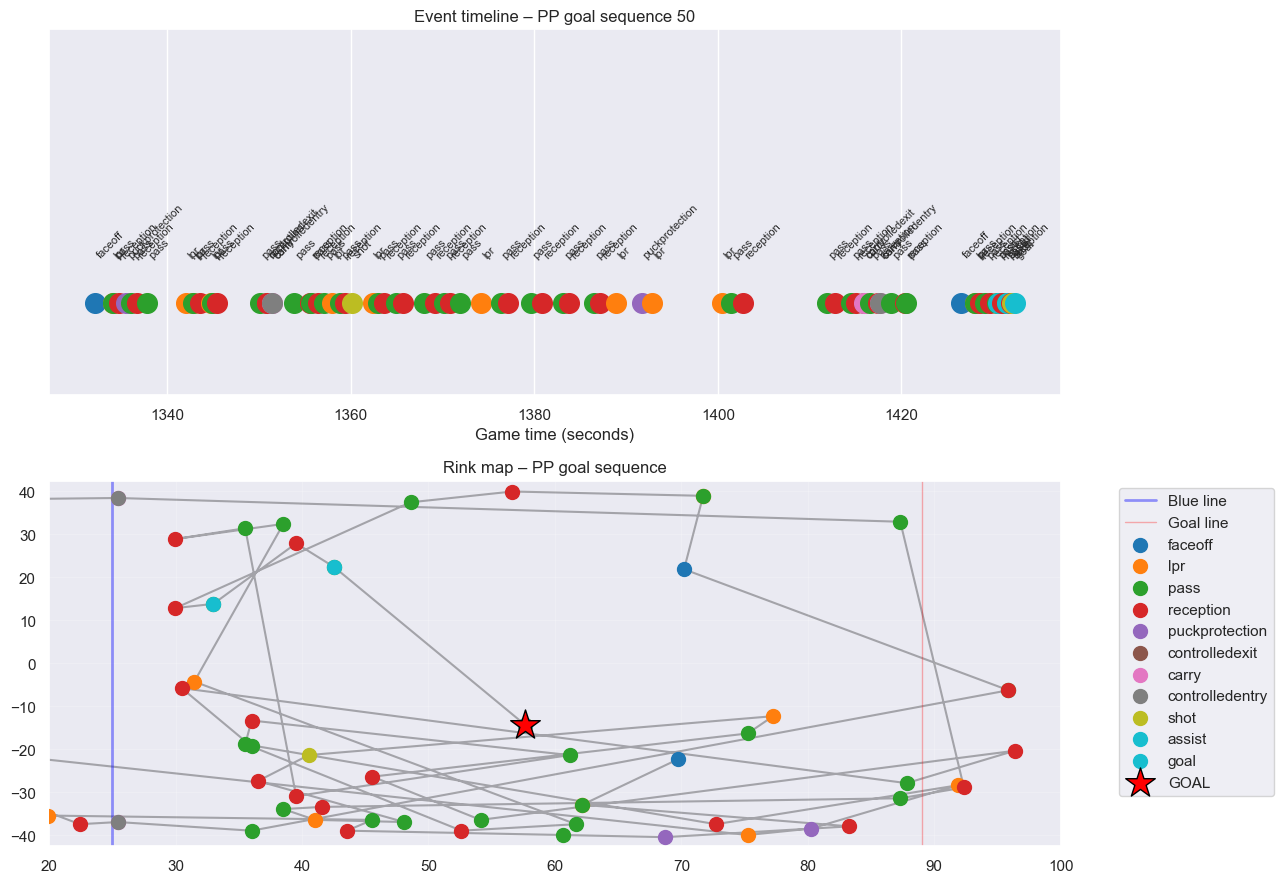

In [7]:
goal_id_to_plot = 50
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

evts = single_seq['eventname'].unique()
cmap = plt.cm.tab10
colors_map = {e: cmap(i / max(len(evts) - 1, 1)) for i, e in enumerate(evts)}

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Event timeline
ax = axes[0]
for _, row in single_seq.iterrows():
    ax.scatter(row['compiledgametime'], 1, color=colors_map[row['eventname']], s=200, zorder=3)
    ax.text(row['compiledgametime'], 1.05, row['eventname'], rotation=45, ha='left', fontsize=8)
ax.set_title(f'Event timeline – PP goal sequence {goal_id_to_plot}')
ax.set_xlabel('Game time (seconds)'); ax.set_yticks([]); ax.set_ylim(0.9, 1.3)

# Rink map
ax = axes[1]
ax.axvline(25, color='blue', linewidth=2, alpha=0.4, label='Blue line')
ax.axvline(89, color='red', linewidth=1, alpha=0.3, label='Goal line')
ax.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], color='black', alpha=0.3, zorder=1)
for evt in evts:
    sub = single_seq[single_seq['eventname'] == evt]
    ax.scatter(sub['xadjcoord'], sub['yadjcoord'], label=evt, s=100, zorder=3, color=colors_map[evt])
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'],
               color='red', marker='*', s=500, label='GOAL', zorder=5, edgecolors='black')
ax.set_xlim(20, 100); ax.set_ylim(-42.5, 42.5)
ax.set_title('Rink map – PP goal sequence')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

### Last 10 events before a PP goal – sequence & transition analysis

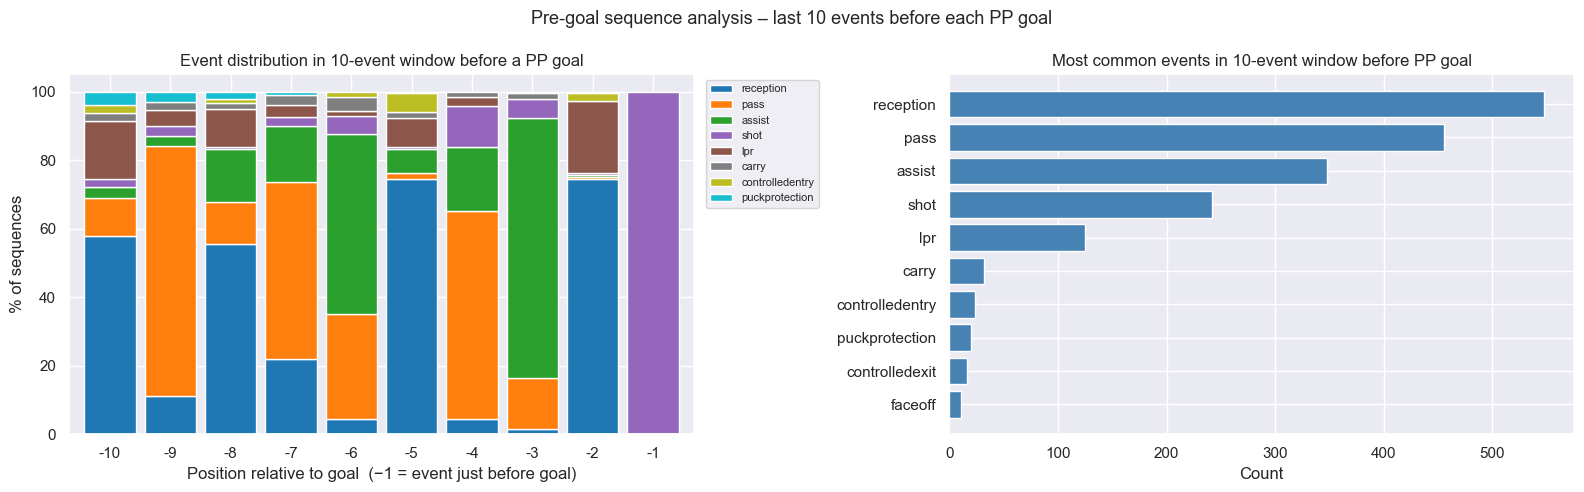

Event counts in 10-event pre-goal window:
eventname
reception          548
pass               456
assist             348
shot               242
lpr                125
carry               32
controlledentry     24
puckprotection      20
controlledexit      16
faceoff             11
Name: count, dtype: int64


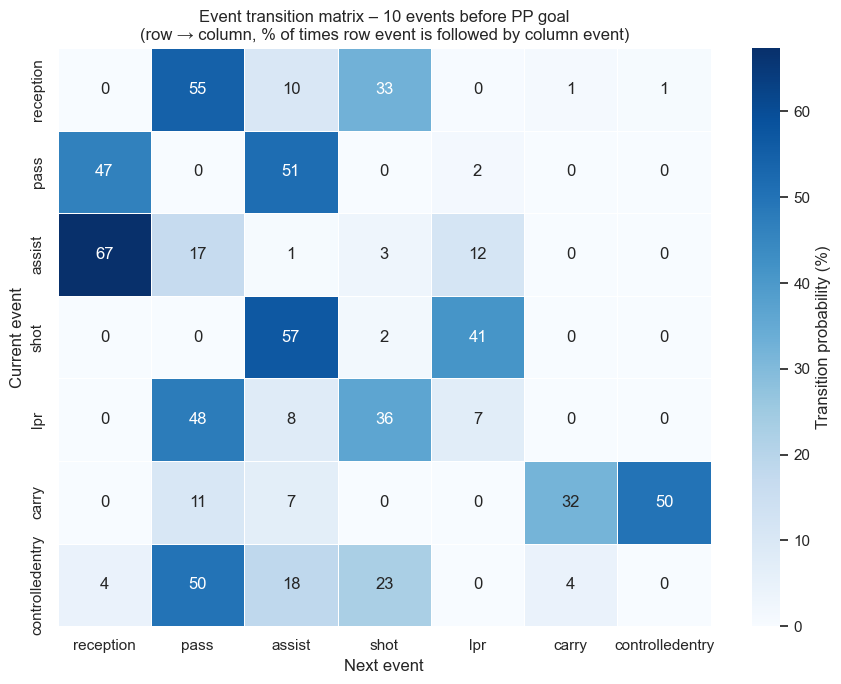

In [8]:
from collections import defaultdict

# Build a record for every event in the 10-event window before each PP goal
pre_goal_records = []

for goal_id, seq in pp_sequences.groupby('goal_id'):
    seq = seq.sort_values('compiledgametime')
    goal_row = seq[seq['eventname'] == 'goal']
    if goal_row.empty:
        continue
    goal_time = goal_row['compiledgametime'].iloc[0]
    pre = seq[seq['compiledgametime'] < goal_time]
    last_10 = pre.tail(10).reset_index(drop=True)
    n = len(last_10)
    for i, (_, row) in enumerate(last_10.iterrows()):
        pre_goal_records.append({
            'goal_id':   goal_id,
            'pos':       i - n,   # -n … -1;  -1 = event immediately before goal
            'eventname': row['eventname'],
        })

pre_goal_df = pd.DataFrame(pre_goal_records)
freq = pre_goal_df['eventname'].value_counts()
top_events = freq.head(8).index.tolist()

# --- Plot 1: stacked bar by position + overall frequency ---
pivot = pre_goal_df.pivot_table(index='pos', columns='eventname', aggfunc='size', fill_value=0)
pivot_pct = pivot[top_events].div(pivot[top_events].sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', width=0.85)
axes[0].set_xlabel('Position relative to goal  (−1 = event just before goal)')
axes[0].set_ylabel('% of sequences')
axes[0].set_title('Event distribution in 10-event window before a PP goal')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

axes[1].barh(freq.index[:10][::-1], freq.values[:10][::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Count')
axes[1].set_title('Most common events in 10-event window before PP goal')

plt.suptitle('Pre-goal sequence analysis – last 10 events before each PP goal', fontsize=13)
plt.tight_layout()
plt.show()

print('Event counts in 10-event pre-goal window:')
print(freq.head(10))

# --- Plot 2: event transition matrix ---
transitions = defaultdict(lambda: defaultdict(int))
for goal_id, grp in pre_goal_df.groupby('goal_id'):
    evts = grp.sort_values('pos')['eventname'].tolist()
    for a, b in zip(evts[:-1], evts[1:]):
        transitions[a][b] += 1

top7 = freq.head(7).index.tolist()
trans_matrix = pd.DataFrame(
    {col: [transitions[row][col] for row in top7] for col in top7},
    index=top7
)
trans_pct = trans_matrix.div(trans_matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(trans_pct.fillna(0).round(1), annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Transition probability (%)'})
ax.set_title('Event transition matrix – 10 events before PP goal\n(row → column, % of times row event is followed by column event)')
ax.set_xlabel('Next event')
ax.set_ylabel('Current event')
plt.tight_layout()
plt.show()

### Clustering PP goal sequences

Average features per cluster:
         x_mean  x_min  y_std  num_passes  num_carries  total_events  duration
cluster                                                                       
0         57.73  23.43  21.70       10.16         0.14         30.33     29.06
1         31.74 -88.78  24.82       20.84         3.57         64.79     76.69
2         34.70 -97.57  25.10       87.75        15.25        257.75    308.98


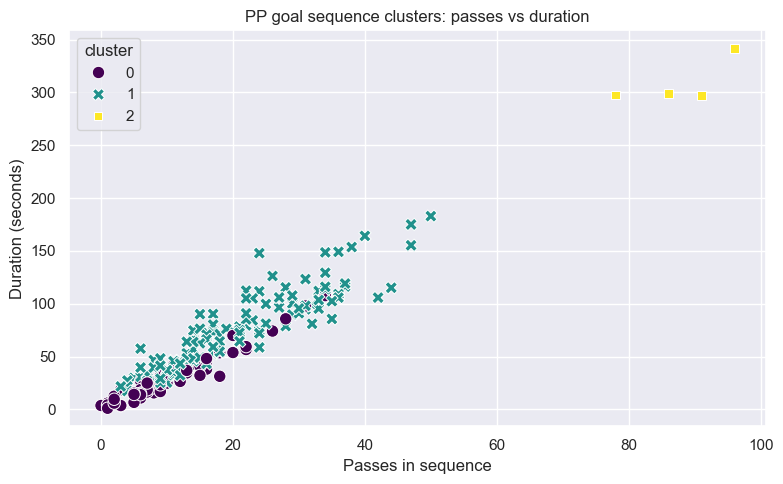

In [9]:
def create_seq_features(df_seqs):
    return df_seqs.groupby('goal_id').agg(
        x_mean=('xadjcoord', 'mean'),
        x_min=('xadjcoord', 'min'),
        y_std=('yadjcoord', 'std'),
        num_passes=('eventname', lambda x: (x == 'pass').sum()),
        num_carries=('eventname', lambda x: (x == 'carry').sum()),
        total_events=('eventname', 'count'),
        duration=('compiledgametime', lambda x: x.max() - x.min())
    ).fillna(0)

seq_feat_df = create_seq_features(pp_sequences)
X_seq = StandardScaler().fit_transform(seq_feat_df)
seq_feat_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_seq)

if 'cluster' in pp_sequences.columns:
    pp_sequences = pp_sequences.drop(columns=['cluster'])
pp_sequences = pp_sequences.merge(seq_feat_df['cluster'].reset_index(), on='goal_id', how='left')

print('Average features per cluster:')
print(seq_feat_df.groupby('cluster').mean().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=seq_feat_df, x='num_passes', y='duration',
                hue='cluster', palette='viridis', s=80, style='cluster', ax=ax)
ax.set_title('PP goal sequence clusters: passes vs duration')
ax.set_xlabel('Passes in sequence'); ax.set_ylabel('Duration (seconds)')
plt.tight_layout(); plt.show()

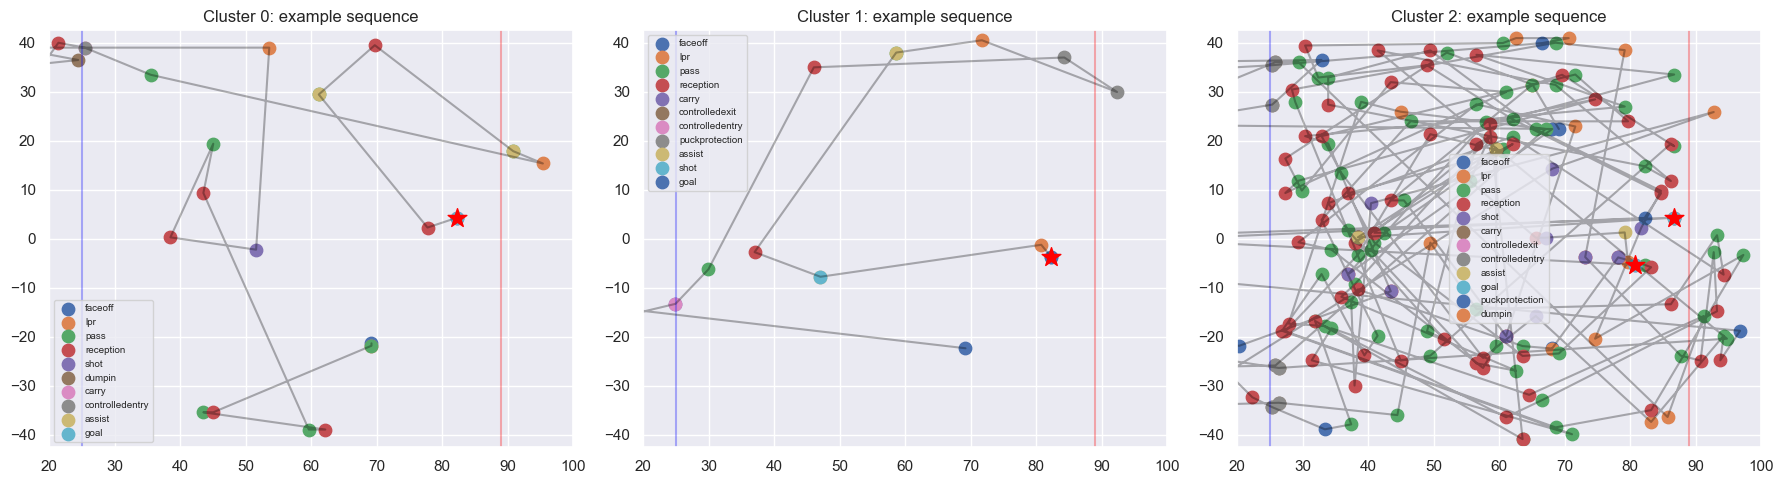

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    example_id = seq_feat_df[seq_feat_df['cluster'] == i].index[0]
    example_seq = pp_sequences[pp_sequences['goal_id'] == example_id]
    ax = axes[i]
    ax.axvline(25, color='blue', alpha=0.3)
    ax.axvline(89, color='red', alpha=0.3)
    ax.plot(example_seq['xadjcoord'], example_seq['yadjcoord'], color='black', alpha=0.3)
    for evt in example_seq['eventname'].unique():
        sub = example_seq[example_seq['eventname'] == evt]
        ax.scatter(sub['xadjcoord'], sub['yadjcoord'], label=evt, s=80)
    goal_row = example_seq[example_seq['eventname'] == 'goal']
    if not goal_row.empty:
        ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'],
                   color='red', marker='*', s=200, zorder=5)
    ax.set_title(f'Cluster {i}: example sequence')
    ax.set_xlim(20, 100); ax.set_ylim(-42.5, 42.5)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Zone entry type

#### Does how the team enters the offensive zone affect whether they score?

In [11]:
entry_conv = seq_df[seq_df['entry_type'] != 'no_entry'].groupby('entry_type').agg(
    n=('goal', 'count'),
    conversion=('goal', 'mean'),
    avg_passes=('n_passes', 'mean'),
    avg_shots=('n_shots', 'mean'),
    avg_xg=('mean_xg', 'mean'),
).reset_index()
entry_conv['conversion'] *= 100
print(entry_conv.round(2).to_string(index=False))

entry_type   n  conversion  avg_passes  avg_shots  avg_xg
     carry 570       15.96       22.96       2.93    0.06
      pass 195       18.46       23.55       2.97    0.06


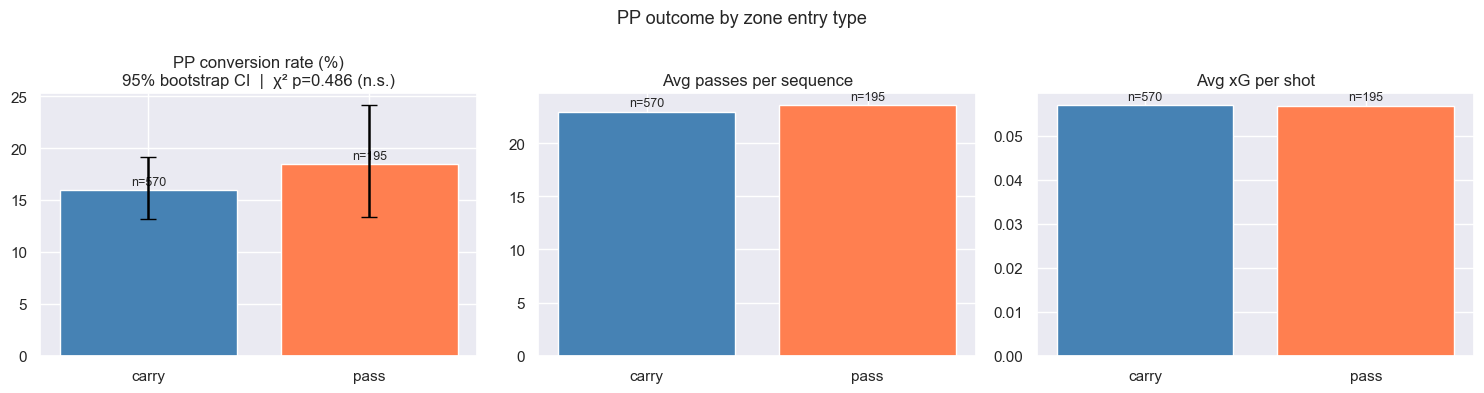

In [12]:
# Bootstrap 95% CI for each entry type's conversion rate
def boot_conv_ci(binary_arr, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    arr = np.array(binary_arr)
    means = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5]) * 100

entry_conv_plot = entry_conv.copy()
entry_conv_plot['ci_lo'] = [boot_conv_ci(seq_df[seq_df['entry_type'] == et]['goal'].values)[0]
                             for et in entry_conv_plot['entry_type']]
entry_conv_plot['ci_hi'] = [boot_conv_ci(seq_df[seq_df['entry_type'] == et]['goal'].values)[1]
                             for et in entry_conv_plot['entry_type']]

# Chi-squared test: is the conversion difference statistically significant?
contingency = np.array([
    [seq_df[seq_df['entry_type'] == et]['goal'].sum(),
     (seq_df['entry_type'] == et).sum() - seq_df[seq_df['entry_type'] == et]['goal'].sum()]
    for et in entry_conv_plot['entry_type']
])
chi2_stat, p_chi2, _, _ = stats.chi2_contingency(contingency)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, title in zip(axes,
    ['conversion', 'avg_passes', 'avg_xg'],
    ['PP conversion rate (%)', 'Avg passes per sequence', 'Avg xG per shot']):

    bars = ax.bar(entry_conv_plot['entry_type'], entry_conv_plot[col],
                  color=colors[:len(entry_conv_plot)], edgecolor='white')

    if col == 'conversion':
        # Error bars showing bootstrap 95% CI
        ax.errorbar(
            range(len(entry_conv_plot)),
            entry_conv_plot['conversion'],
            yerr=[entry_conv_plot['conversion'] - entry_conv_plot['ci_lo'],
                  entry_conv_plot['ci_hi'] - entry_conv_plot['conversion']],
            fmt='none', color='black', capsize=6, linewidth=1.8, zorder=5
        )
        sig = 'n.s.' if p_chi2 >= 0.05 else 'p < 0.05'
        ax.set_title(f'{title}\n95% bootstrap CI  |  χ² p={p_chi2:.3f} ({sig})')
    else:
        ax.set_title(title)

    for bar, n in zip(bars, entry_conv_plot['n']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ax.get_ylim()[1] * 0.02,
                f'n={n}', ha='center', fontsize=9)
    ax.set_xlabel('')

plt.suptitle('PP outcome by zone entry type', fontsize=13)
plt.tight_layout()
plt.show()

### Shot quality after each entry type

/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_44094/2822139673.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,
/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_44094/2822139673.py:24: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,


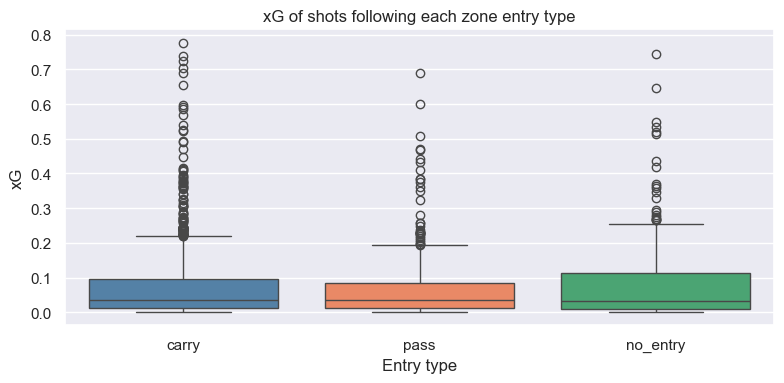

             count    mean     std     min     25%     50%     75%     max
entry_type                                                                
carry       1577.0  0.0696  0.0929  0.0015  0.0120  0.0348  0.0947  0.7765
no_entry     310.0  0.0809  0.1112  0.0016  0.0102  0.0336  0.1117  0.7440
pass         542.0  0.0651  0.0864  0.0014  0.0109  0.0346  0.0844  0.6902


In [13]:
pp_data = data[data['manpowersituation'] == 'powerPlay'].copy().sort_values(['gameid', 'compiledgametime'])

# Tag each shot with the most recent entry type in the same sequence
pp_data['time_gap'] = pp_data.groupby('gameid')['compiledgametime'].diff()
pp_data['new_seq']  = (pp_data['time_gap'] > 10) | pp_data['time_gap'].isna()
pp_data['seq_id']   = pp_data.groupby('gameid')['new_seq'].cumsum()

tagged = []
for (game, seq), grp in pp_data.groupby(['gameid', 'seq_id']):
    entries = grp[grp['eventname'] == 'controlledentry']['type']
    if len(entries) == 0: etype = 'no_entry'
    else:
        t = entries.iloc[0]
        etype = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')
    shots = grp[grp['eventname'].isin(['shot', 'goal'])].dropna(subset=['xg_allattempts']).copy()
    shots['entry_type'] = etype
    tagged.append(shots)

tagged_shots = pd.concat(tagged, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
order = ['carry', 'pass', 'other', 'no_entry']
order = [o for o in order if o in tagged_shots['entry_type'].unique()]
sns.boxplot(data=tagged_shots, x='entry_type', y='xg_allattempts', order=order,
            palette=['steelblue','coral','mediumseagreen','gray'], ax=ax)
ax.set_title('xG of shots following each zone entry type')
ax.set_xlabel('Entry type'); ax.set_ylabel('xG')
plt.tight_layout(); plt.show()

print(tagged_shots.groupby('entry_type')['xg_allattempts'].describe().round(4))

# Puck movement and shot quality

#### Passes by the attacking team in the 10 seconds before each shot (same team in possession).

In [14]:
shots = pp_data[pp_data['eventname'].isin(['shot', 'goal'])].dropna(subset=['xg_allattempts', 'teaminpossession']).copy()

passes_df = pp_data[pp_data['eventname'] == 'pass'][
    ['gameid', 'teaminpossession', 'compiledgametime']
].dropna(subset=['teaminpossession']).copy().rename(columns={'compiledgametime': 'pass_time'})

counts = []
for game_id, g_shots in shots.groupby('gameid'):
    g_passes = passes_df[passes_df['gameid'] == game_id]
    for _, row in g_shots.iterrows():
        tp = g_passes[g_passes['teaminpossession'] == row['teaminpossession']]['pass_time'].values
        t  = row['compiledgametime']
        counts.append(int(((tp >= t - 10) & (tp < t)).sum()))

shots['passes_before'] = counts
shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(10)

,mean,count
passes_before,,
0,0.050547,24
1,0.045053,174
2,0.056487,427
3,0.070210,622
4,0.073386,612
5,0.083210,379
6,0.092262,151
7,0.070081,38
8,0.032160,1


### Mann-Whitney U test – few vs many passes before shot

In [15]:
few  = shots[shots['passes_before'] <= 2]['xg_allattempts']
many = shots[shots['passes_before'] >= 4]['xg_allattempts']
stat, p = stats.mannwhitneyu(few, many, alternative='less')

print(f'n (≤2 passes): {len(few)},  median xG = {few.median():.4f}')
print(f'n (≥4 passes): {len(many)},  median xG = {many.median():.4f}')
print(f'U = {stat:.0f},  p = {p:.4f}')
print('Significant (p < 0.05)' if p < 0.05 else 'Not significant')

n (≤2 passes): 625,  median xG = 0.0272
n (≥4 passes): 1182,  median xG = 0.0420
U = 301427,  p = 0.0000
Significant (p < 0.05)


### Bootstrap 95% CI on mean xG per pass count

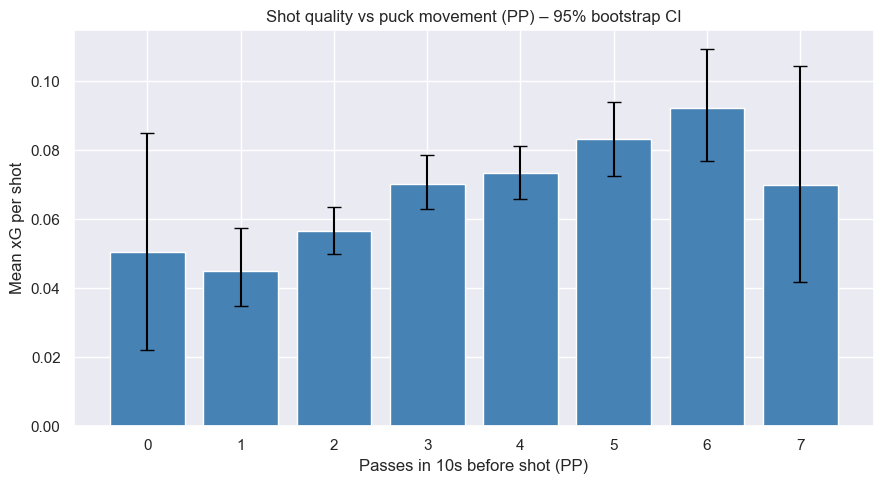

 passes   n  mean_xg  ci_lo  ci_hi
      0  24   0.0505 0.0220 0.0851
      1 174   0.0451 0.0349 0.0575
      2 427   0.0565 0.0498 0.0635
      3 622   0.0702 0.0630 0.0786
      4 612   0.0734 0.0659 0.0813
      5 379   0.0832 0.0726 0.0941
      6 151   0.0923 0.0768 0.1093
      7  38   0.0701 0.0417 0.1044


In [16]:
def bootstrap_ci(arr, n_boot=2000):
    arr = np.asarray(arr)
    means = [np.random.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

rows = []
for n in range(0, 8):
    sub = shots[shots['passes_before'] == n]['xg_allattempts']
    if len(sub) < 10: continue
    lo, hi = bootstrap_ci(sub)
    rows.append({'passes': n, 'n': len(sub), 'mean_xg': sub.mean(), 'ci_lo': lo, 'ci_hi': hi})

ci_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ci_df['passes'], ci_df['mean_xg'], color='steelblue', edgecolor='white')
ax.errorbar(ci_df['passes'], ci_df['mean_xg'],
            yerr=[ci_df['mean_xg'] - ci_df['ci_lo'], ci_df['ci_hi'] - ci_df['mean_xg']],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xlabel('Passes in 10s before shot (PP)')
ax.set_ylabel('Mean xG per shot')
ax.set_title('Shot quality vs puck movement (PP) – 95% bootstrap CI')
plt.tight_layout(); plt.show()

print(ci_df[['passes', 'n', 'mean_xg', 'ci_lo', 'ci_hi']].round(4).to_string(index=False))

### Shot location heatmap (PP) – where do shots and goals originate?

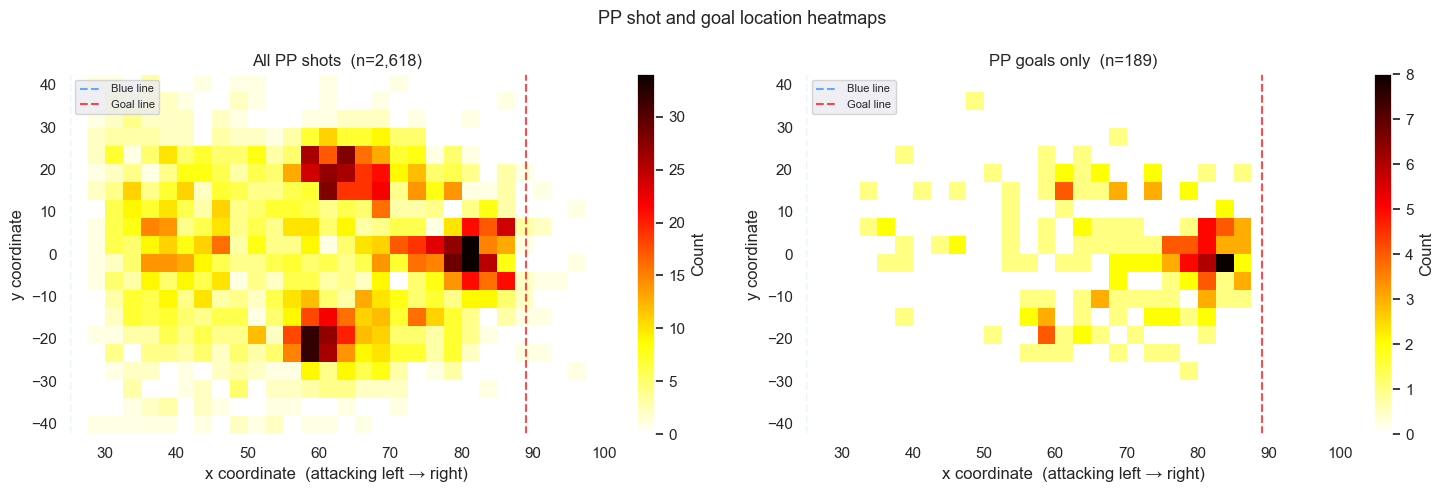

Median shot distance from goal:  33.1 ft
Median GOAL distance from goal:  20.7 ft


In [17]:
pp_shots_loc = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'].isin(['shot', 'goal']))
].dropna(subset=['xadjcoord', 'yadjcoord'])

pp_goals_loc = pp_shots_loc[pp_shots_loc['eventname'] == 'goal']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, subset, title in zip(
    axes,
    [pp_shots_loc, pp_goals_loc],
    [f'All PP shots  (n={len(pp_shots_loc):,})', f'PP goals only  (n={len(pp_goals_loc)})']
):
    h = ax.hist2d(
        subset['xadjcoord'], subset['yadjcoord'],
        bins=[30, 20], range=[[25, 100], [-42.5, 42.5]],
        cmap='hot_r'
    )
    plt.colorbar(h[3], ax=ax, label='Count')
    ax.axvline(25, color='dodgerblue', linewidth=1.5, alpha=0.7, linestyle='--', label='Blue line')
    ax.axvline(89, color='red',        linewidth=1.5, alpha=0.7, linestyle='--', label='Goal line')
    ax.set_xlim(25, 100); ax.set_ylim(-42.5, 42.5)
    ax.set_title(title)
    ax.set_xlabel('x coordinate  (attacking left → right)')
    ax.set_ylabel('y coordinate')
    ax.legend(fontsize=8)

plt.suptitle('PP shot and goal location heatmaps', fontsize=13)
plt.tight_layout()
plt.show()

# Median shot distance from goal (x=89)
pp_shots_loc = pp_shots_loc.copy()
pp_shots_loc['dist_to_goal'] = np.sqrt((pp_shots_loc['xadjcoord'] - 89)**2 + pp_shots_loc['yadjcoord']**2)
pp_goals_loc = pp_shots_loc[pp_shots_loc['eventname'] == 'goal']

print(f"Median shot distance from goal:  {pp_shots_loc['dist_to_goal'].median():.1f} ft")
print(f"Median GOAL distance from goal:  {pp_goals_loc['dist_to_goal'].median():.1f} ft")

# When in the PP do goals happen?

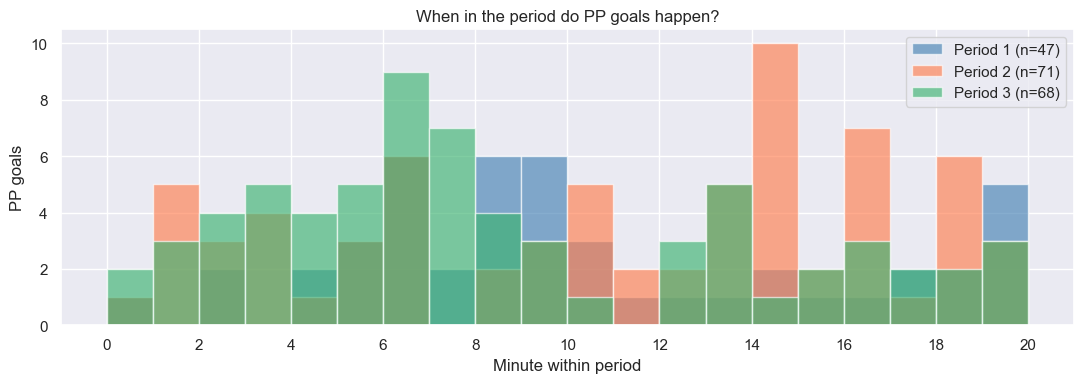

In [18]:
pp_goals_time = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'goal') &
    (data['period'].isin([1, 2, 3]))
].copy()

pp_goals_time['time_in_period_s'] = pp_goals_time['compiledgametime'] - (pp_goals_time['period'] - 1) * 1200
pp_goals_time['minute_in_period']  = pp_goals_time['time_in_period_s'] / 60
pp_goals_time['5min_bin']          = (pp_goals_time['minute_in_period'] // 5 * 5).clip(0, 15).astype(int)
pp_goals_time['5min_label']        = pp_goals_time['5min_bin'].astype(str) + '-' + (pp_goals_time['5min_bin'] + 5).astype(str)

fig, ax = plt.subplots(figsize=(11, 4))
period_colors = {1: 'steelblue', 2: 'coral', 3: 'mediumseagreen'}
for p in [1, 2, 3]:
    subset = pp_goals_time[pp_goals_time['period'] == p]['minute_in_period']
    ax.hist(subset, bins=20, range=(0, 20), alpha=0.65,
            label=f'Period {p} (n={len(subset)})', color=period_colors[p], edgecolor='white')
ax.set_xlabel('Minute within period'); ax.set_ylabel('PP goals')
ax.set_xticks(range(0, 21, 2)); ax.legend()
ax.set_title('When in the period do PP goals happen?')
plt.tight_layout(); plt.show()

### PP goals by period × 5-minute segment

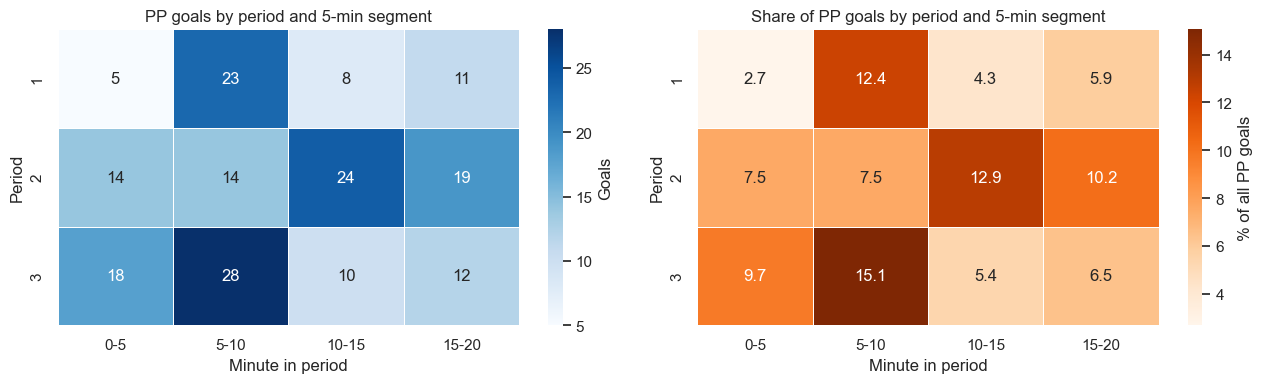

In [19]:
bin_labels = ['0-5', '5-10', '10-15', '15-20']
goal_matrix  = pp_goals_time.groupby(['period', '5min_label']).size().unstack(fill_value=0).reindex(columns=bin_labels, fill_value=0)
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(goal_matrix,  annot=True, fmt='d',   cmap='Blues',   ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Goals'})
axes[0].set_title('PP goals by period and 5-min segment')
axes[0].set_xlabel('Minute in period'); axes[0].set_ylabel('Period')
sns.heatmap(share_matrix, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], linewidths=0.5, cbar_kws={'label': '% of all PP goals'})
axes[1].set_title('Share of PP goals by period and 5-min segment')
axes[1].set_xlabel('Minute in period'); axes[1].set_ylabel('Period')
plt.tight_layout(); plt.show()

### Score differential when PP goal is scored

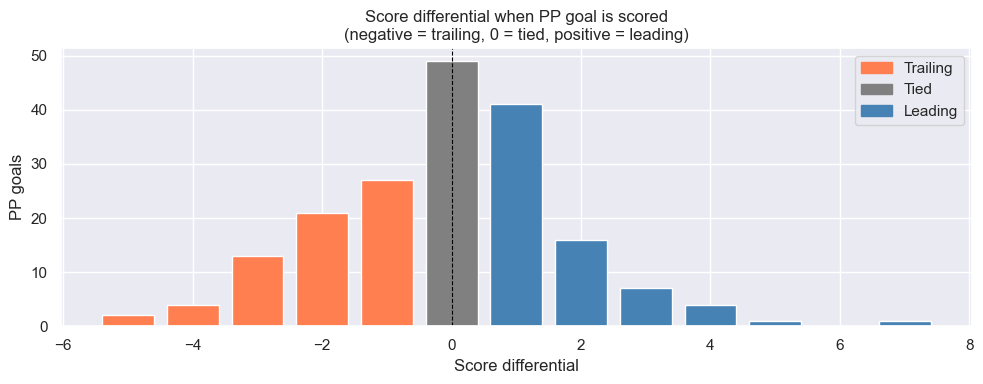

In [20]:
score_counts = pp_goals_time['scoredifferential'].value_counts().sort_index()
colors = ['coral' if x < 0 else 'steelblue' if x > 0 else 'gray' for x in score_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
ax.set_title('Score differential when PP goal is scored\n(negative = trailing, 0 = tied, positive = leading)')
ax.set_xlabel('Score differential'); ax.set_ylabel('PP goals')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(handles=[Patch(color='coral', label='Trailing'), Patch(color='gray', label='Tied'), Patch(color='steelblue', label='Leading')])
plt.tight_layout(); plt.show()

# Goals scored after the PP ends – carry-over

#### Even-strength goals where the scoring team had PP activity in the 30 seconds before.

In [21]:
es_goals = data[
    (data['eventname'] == 'goal') &
    (data['manpowersituation'] == 'evenStrength')
].copy()
es_goals['is_carryover']    = False
es_goals['seconds_after_pp'] = np.nan

for game_id, game_df in data.groupby('gameid'):
    game_es = es_goals[es_goals['gameid'] == game_id]
    if len(game_es) == 0: continue
    game_pp = game_df[game_df['manpowersituation'] == 'powerPlay']
    for idx, goal in game_es.iterrows():
        t, team = goal['compiledgametime'], goal['teamid']
        prior_pp = game_pp[
            (game_pp['teamid'] == team) &
            (game_pp['compiledgametime'] < t) &
            (game_pp['compiledgametime'] >= t - 30)
        ]
        if len(prior_pp) > 0:
            es_goals.at[idx, 'is_carryover']     = True
            es_goals.at[idx, 'seconds_after_pp'] = t - prior_pp['compiledgametime'].max()

n_total = len(es_goals)
n_carry = int(es_goals['is_carryover'].sum())
print(f'Even-strength goals:             {n_total}')
print(f'Carry-over goals (≤30s after PP): {n_carry} ({n_carry/n_total*100:.1f}%)')

Even-strength goals:             615
Carry-over goals (≤30s after PP): 22 (3.6%)


### When exactly do carry-over goals happen?

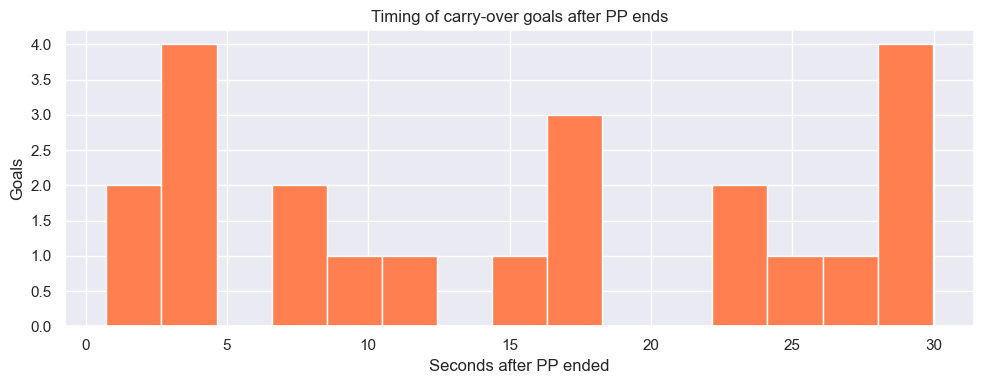

count    22.0
mean     15.3
std      10.5
min       0.7
25%       5.1
50%      16.0
75%      25.0
max      30.0
Name: seconds_after_pp, dtype: float64


In [22]:
carry = es_goals[es_goals['is_carryover']].dropna(subset=['seconds_after_pp'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(carry['seconds_after_pp'], bins=15, color='coral', edgecolor='white')
ax.set_xlabel('Seconds after PP ended')
ax.set_ylabel('Goals')
ax.set_title('Timing of carry-over goals after PP ends')
plt.tight_layout(); plt.show()

print(carry['seconds_after_pp'].describe().round(1))

### What characterizes PP sequences that lead to carry-over goals?

#### Compare seq_df features: sequences followed by a carry-over goal vs those that aren't.

In [23]:
# Match each PP sequence to whether it was followed by a carry-over goal within 30s
carry_game_times = es_goals[es_goals['is_carryover']][['gameid', 'teamid', 'compiledgametime']].copy()
carry_game_times = carry_game_times.rename(columns={'compiledgametime': 'goal_time'})

# Rebuild sequences with gameid and end time
pp_seq_full = []
for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()
    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) < 3: continue
        team = seq['teamid'].mode()[0]
        end_t = seq['compiledgametime'].max()
        # check if a carry-over goal from this team follows within 30s
        co = carry_game_times[
            (carry_game_times['gameid'] == game) &
            (carry_game_times['teamid'] == team) &
            (carry_game_times['goal_time'] > end_t) &
            (carry_game_times['goal_time'] <= end_t + 30)
        ]
        entries = seq[seq['eventname'] == 'controlledentry']['type']
        etype = 'no_entry'
        if len(entries) > 0:
            t = entries.iloc[0]
            etype = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')

        pp_seq_full.append({
            'carryover':  int(len(co) > 0),
            'n_passes':   (seq['eventname'] == 'pass').sum(),
            'n_shots':    seq['eventname'].isin(['shot','goal']).sum(),
            'duration':   end_t - seq['compiledgametime'].min(),
            'entry_type': etype,
            'mean_xg':    seq['xg_allattempts'].mean() if seq['xg_allattempts'].notna().any() else 0,
        })

co_df = pd.DataFrame(pp_seq_full)
print(f'Sequences followed by carry-over goal: {co_df["carryover"].sum()} ({co_df["carryover"].mean()*100:.1f}%)')
print()
print(co_df.groupby('carryover')[['n_passes','n_shots','duration','mean_xg']].mean().round(2))

Sequences followed by carry-over goal: 22 (2.3%)

           n_passes  n_shots  duration  mean_xg
carryover                                      
0             20.21     2.71     79.49     0.06
1             21.55     3.32     87.24     0.09


/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_44094/3338884804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=co_df, x='carryover', y=feat, palette={'0': 'steelblue', '1': 'coral'}, ax=ax)
/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_44094/3338884804.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No carry-over', 'Carry-over'])
/var/folders/v8/rkz49_9s6z71fq6sxs_b6zk40000gn/T/ipykernel_44094/3338884804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=co_df, x='carryover', y=feat, palette={'0': 'steelblue', '1': 'coral'}, ax=ax)
/var/folde

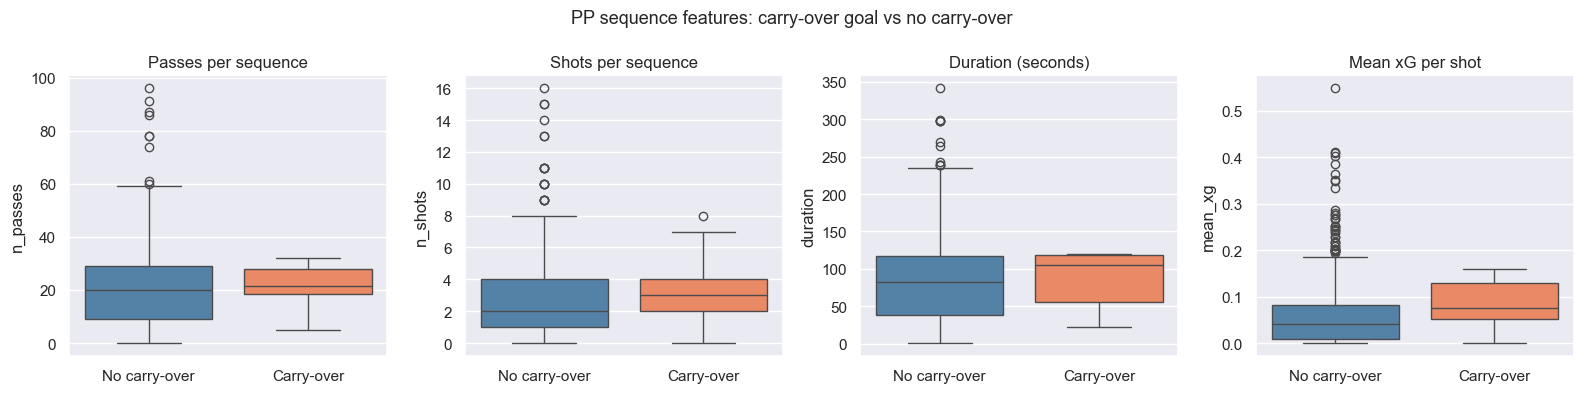

In [24]:
features = ['n_passes', 'n_shots', 'duration', 'mean_xg']
titles   = ['Passes per sequence', 'Shots per sequence', 'Duration (seconds)', 'Mean xG per shot']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat, title in zip(axes, features, titles):
    sns.boxplot(data=co_df, x='carryover', y=feat, palette={'0': 'steelblue', '1': 'coral'}, ax=ax)
    ax.set_xticklabels(['No carry-over', 'Carry-over'])
    ax.set_title(title); ax.set_xlabel('')
plt.suptitle('PP sequence features: carry-over goal vs no carry-over', fontsize=13)
plt.tight_layout(); plt.show()

In [25]:
for feat in ['n_passes', 'n_shots', 'duration', 'mean_xg']:
    g0 = co_df[co_df['carryover'] == 0][feat].dropna()
    g1 = co_df[co_df['carryover'] == 1][feat].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='less')
    sig = '✓ significant' if p < 0.05 else '✗ not significant'
    print(f'{feat:<12}  median no-co={g0.median():.2f}  median co={g1.median():.2f}  p={p:.4f}  {sig}')

n_passes      median no-co=20.00  median co=21.50  p=0.2222  ✗ not significant
n_shots       median no-co=2.00  median co=3.00  p=0.0579  ✗ not significant
duration      median no-co=81.84  median co=105.76  p=0.1130  ✗ not significant
mean_xg       median no-co=0.04  median co=0.08  p=0.0008  ✓ significant


### Carry-over rate by zone entry type

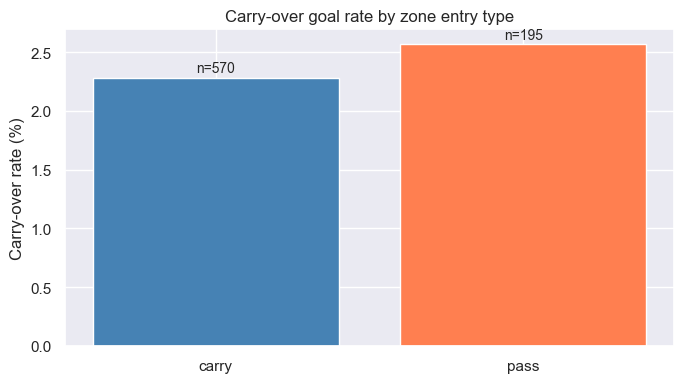

entry_type   n  carry_rate
     carry 570    2.280702
      pass 195    2.564103


In [26]:
# Carry-over rate by zone entry type
co_entry = co_df[co_df['entry_type'] != 'no_entry'].groupby('entry_type').agg(
    n=('carryover', 'count'),
    carry_rate=('carryover', 'mean')
).reset_index()
co_entry['carry_rate'] *= 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(co_entry['entry_type'], co_entry['carry_rate'],
              color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
for bar, n in zip(bars, co_entry['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'n={n}', ha='center', fontsize=10)
ax.set_ylabel('Carry-over rate (%)')
ax.set_title('Carry-over goal rate by zone entry type')
plt.tight_layout()
plt.show()

print(co_entry.to_string(index=False))

### Last event of the PP before a carry-over goal

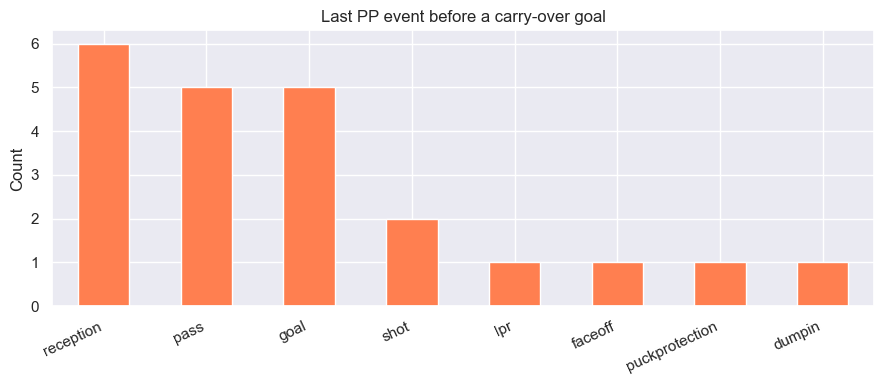

reception         6
pass              5
goal              5
shot              2
lpr               1
faceoff           1
puckprotection    1
dumpin            1
Name: count, dtype: int64


In [27]:
# For carry-over sequences, what was the last event before the PP ended?
last_pp_events = []
carry_game_times = es_goals[es_goals['is_carryover']][['gameid', 'teamid', 'compiledgametime']].copy()
carry_game_times = carry_game_times.rename(columns={'compiledgametime': 'goal_time'})

for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()

    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) < 3: continue
        team  = seq['teamid'].mode()[0]
        end_t = seq['compiledgametime'].max()
        co = carry_game_times[
            (carry_game_times['gameid'] == game) &
            (carry_game_times['teamid'] == team) &
            (carry_game_times['goal_time'] > end_t) &
            (carry_game_times['goal_time'] <= end_t + 30)
        ]
        if len(co) > 0:
            last_event = seq.iloc[-1]['eventname']
            last_pp_events.append(last_event)

last_event_counts = pd.Series(last_pp_events).value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
last_event_counts.head(10).plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Last PP event before a carry-over goal')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(last_event_counts.head(10))

### Per-team carry-over breakdown

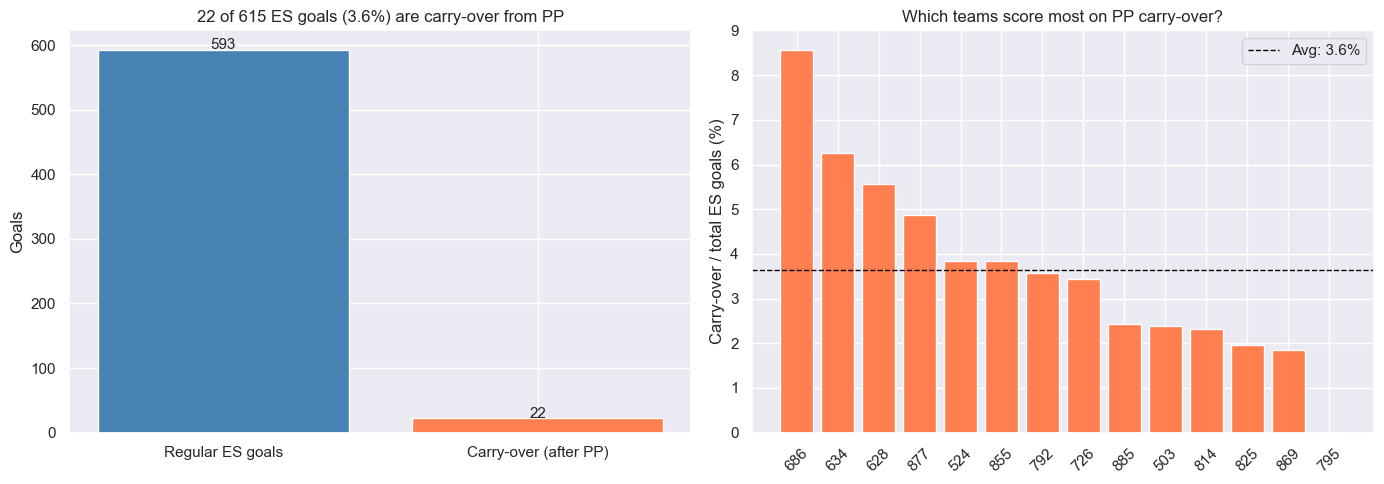

In [28]:
team_carry = es_goals.groupby('teamid').agg(
    es_goals_total=('is_carryover', 'count'),
    carry_over=('is_carryover', 'sum')
).reset_index()
team_carry['carry_pct'] = team_carry['carry_over'] / team_carry['es_goals_total'] * 100
team_carry = team_carry.sort_values('carry_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Regular ES goals', 'Carry-over (after PP)'],
            [n_total - n_carry, n_carry], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_ylabel('Goals')
axes[0].set_title(f'{n_carry} of {n_total} ES goals ({n_carry/n_total*100:.1f}%) are carry-over from PP')
for i, v in enumerate([n_total - n_carry, n_carry]):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11)

x = range(len(team_carry))
axes[1].bar(x, team_carry['carry_pct'], color='coral', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(team_carry['teamid'], rotation=45)
axes[1].set_ylabel('Carry-over / total ES goals (%)')
axes[1].set_title('Which teams score most on PP carry-over?')
axes[1].axhline(team_carry['carry_pct'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'Avg: {team_carry["carry_pct"].mean():.1f}%')
axes[1].legend(); plt.tight_layout(); plt.show()

# PP conversion rate per team

#### Bootstrap CI with 1000 iterations.

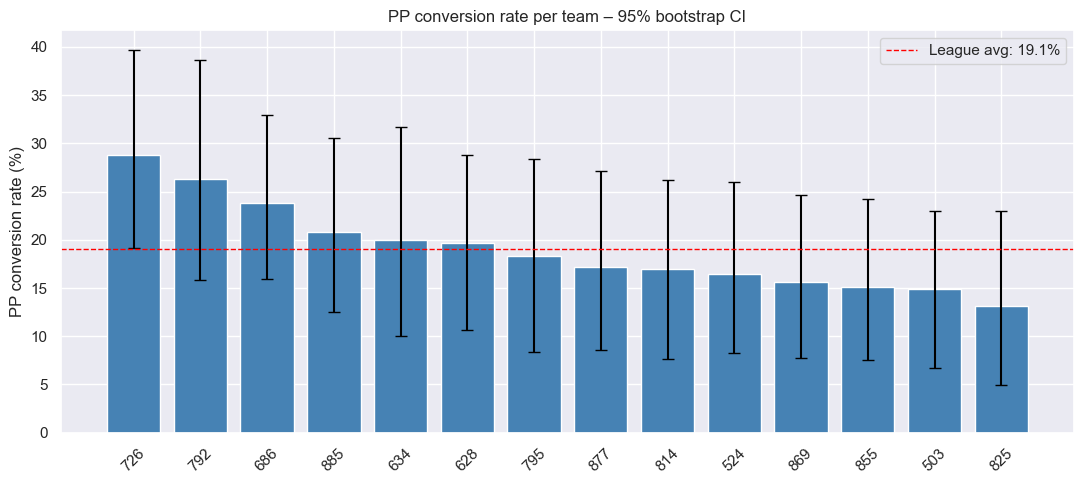

 teamid    pp_pct  n     ci_lo     ci_hi
    726 28.767123 73 19.178082 39.726027
    792 26.315789 57 15.789474 38.596491
    686 23.863636 88 15.909091 32.954545
    885 20.833333 72 12.500000 30.555556
    634 20.000000 60 10.000000 31.666667
    628 19.696970 66 10.606061 28.787879
    795 18.333333 60  8.333333 28.333333
    877 17.142857 70  8.571429 27.142857
    814 16.923077 65  7.692308 26.153846
    524 16.438356 73  8.219178 26.027397
    869 15.584416 77  7.792208 24.675325
    855 15.151515 66  7.575758 24.242424
    503 14.864865 74  6.756757 22.972973
    825 13.114754 61  4.918033 22.950820


In [29]:
team_conv_df = seq_df.groupby('teamid').agg(
    pp_pct=('goal', lambda x: x.mean() * 100),
    n=('goal', 'count')
).reset_index()

def bootstrap_rate_ci(arr, n_boot=1000):
    arr = np.array(arr)
    means = [np.random.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(means, 2.5) * 100, np.percentile(means, 97.5) * 100

cis = [bootstrap_rate_ci(seq_df[seq_df['teamid'] == t]['goal'].values) for t in team_conv_df['teamid']]
team_conv_df['ci_lo'] = [c[0] for c in cis]
team_conv_df['ci_hi'] = [c[1] for c in cis]
team_conv_df = team_conv_df.sort_values('pp_pct', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(team_conv_df))
ax.bar(x, team_conv_df['pp_pct'], color='steelblue', edgecolor='white')
ax.errorbar(x, team_conv_df['pp_pct'],
            yerr=[team_conv_df['pp_pct'] - team_conv_df['ci_lo'],
                  team_conv_df['ci_hi'] - team_conv_df['pp_pct']],
            fmt='none', color='black', capsize=4, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(team_conv_df['teamid'], rotation=45)
ax.set_ylabel('PP conversion rate (%)')
ax.set_title('PP conversion rate per team – 95% bootstrap CI')
ax.axhline(team_conv_df['pp_pct'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'League avg: {team_conv_df["pp_pct"].mean():.1f}%')
ax.legend(); plt.tight_layout(); plt.show()

print(team_conv_df.to_string(index=False))

# Team playing style in PP

#### K-Means clustering on 5 features. Linked to conversion rate to see if style correlates with efficiency.

In [30]:
pp_entries_style = data[
    (data['eventname'] == 'controlledentry') &
    (data['manpowersituation'] == 'powerPlay')
].copy()
pp_entries_style['entry_type'] = pp_entries_style['type'].apply(
    lambda x: 'carry' if str(x).startswith('carry') else ('pass' if str(x).startswith('pass') else 'other')
)
pp_entries_style['corridor'] = pp_entries_style['yadjcoord'].apply(
    lambda y: 'center' if -14 <= y <= 14 else ('left' if y > 14 else 'right')
)

pp_passes_style = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'pass') &
    (data['xadjcoord'] > 20)
].copy()

def assign_zone(row):
    x, y = row['xadjcoord'], row['yadjcoord']
    if x < 50:    return 'point'
    elif x >= 80: return 'behind_net'
    elif y < -15: return 'left_circle'
    elif y > 15:  return 'right_circle'
    else:         return 'slot'

pp_passes_style['zone'] = pp_passes_style.apply(assign_zone, axis=1)

team_rows = []
for team in data['teamid'].unique():
    ent = pp_entries_style[pp_entries_style['teamid'] == team]
    pas = pp_passes_style[pp_passes_style['teamid'] == team]
    if len(ent) < 10 or len(pas) < 20: continue
    team_rows.append({
        'teamid':     team,
        'carry_pct':  (ent['entry_type'] == 'carry').mean() * 100,
        'pass_pct':   (ent['entry_type'] == 'pass').mean()  * 100,
        'center_pct': (ent['corridor']   == 'center').mean()* 100,
        'slot_pct':   (pas['zone']       == 'slot').mean()  * 100,
        'point_pct':  (pas['zone']       == 'point').mean() * 100,
    })

style_df = pd.DataFrame(team_rows)
feat_cols = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']

X = StandardScaler().fit_transform(style_df[feat_cols])
style_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

means = style_df.groupby('cluster')[feat_cols].mean()
label_map = {
    'carry_pct':  'Carry-heavy',
    'pass_pct':   'Pass-based',
    'slot_pct':   'Slot-focused',
    'point_pct':  'Point-oriented',
    'center_pct': 'Center corridor',
}

# Fix: use z-scores of cluster means so the *most distinctive* feature per cluster
# wins the label, not just the feature with the highest absolute value (which is
# always carry_pct and causes all clusters to get the same label).
means_z = (means - means.mean()) / means.std()
style_df['style'] = style_df['cluster'].map(
    {c: label_map.get(means_z.loc[c].idxmax(), f'Style {c+1}') for c in means_z.index}
)

pp_lookup = team_conv_df.set_index('teamid')['pp_pct']
style_df['pp_pct'] = style_df['teamid'].map(pp_lookup)

print('Cluster means (raw %):')
print(means.round(1))
print('\nZ-scored cluster means (used for labeling):')
print(means_z.round(2))
print('\nMean PP% per style:')
print(style_df.groupby('style')[['pp_pct']].mean().round(2))

Cluster means (raw %):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0             66.1      33.9        19.6       3.1       35.4
1             79.8      20.2        18.9       2.7       40.8
2             76.7      23.3        14.8       2.1       35.7

Z-scored cluster means (used for labeling):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0            -1.13      1.13        0.70      0.92      -0.63
1             0.78     -0.78        0.44      0.14       1.15
2             0.35     -0.35       -1.15     -1.06      -0.52

Mean PP% per style:
                pp_pct
style                 
Carry-heavy      17.45
Pass-based       23.21
Point-oriented   17.34


### Radar chart – average style per cluster

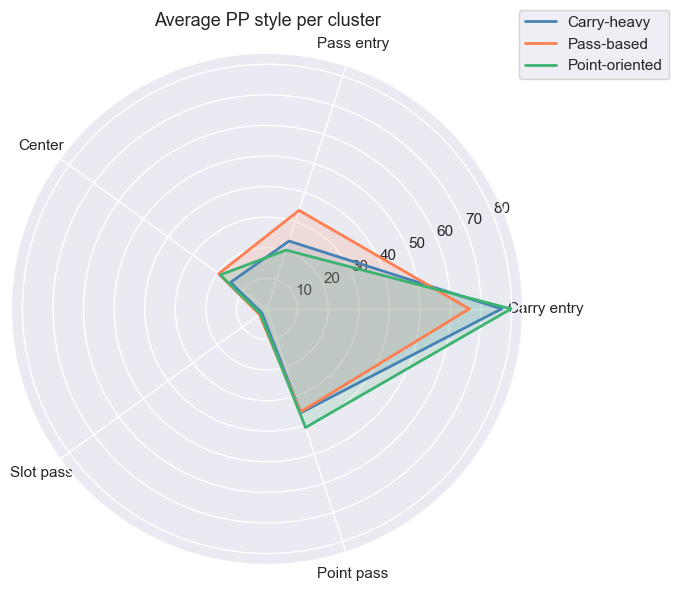

In [ ]:
categories = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']
labels = ['Carry entry', 'Pass entry', 'Center', 'Slot pass', 'Point pass']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = ['steelblue', 'coral', 'mediumseagreen']

for i, (style, grp) in enumerate(style_df.groupby('style')):
    vals = grp[categories].mean().tolist() + [grp[categories].mean().tolist()[0]]
    ax.plot(angles, vals, color=palette[i], linewidth=2, label=style)
    ax.fill(angles, vals, color=palette[i], alpha=0.15)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, size=11)
ax.set_title('Average PP style per cluster', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

### PP conversion rate by playing style

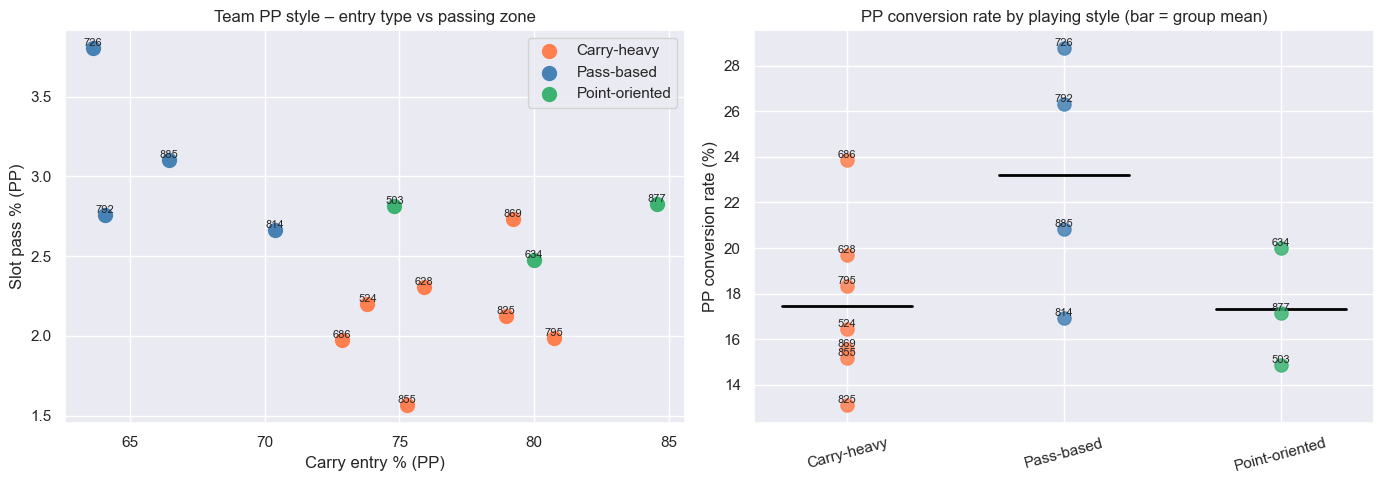

In [32]:
palette = dict(zip(style_df['style'].unique(), ['steelblue', 'coral', 'mediumseagreen']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for style, grp in style_df.groupby('style'):
    axes[0].scatter(grp['carry_pct'], grp['slot_pct'], label=style, s=100, color=palette.get(style, 'gray'))
    for _, row in grp.iterrows():
        axes[0].annotate(str(row['teamid']), (row['carry_pct'], row['slot_pct']), fontsize=8, ha='center', va='bottom')
axes[0].set_xlabel('Carry entry % (PP)'); axes[0].set_ylabel('Slot pass % (PP)')
axes[0].set_title('Team PP style – entry type vs passing zone'); axes[0].legend()

style_order = sorted(style_df['style'].unique())
for i, s in enumerate(style_order):
    grp = style_df[style_df['style'] == s]
    axes[1].scatter([i] * len(grp), grp['pp_pct'], s=90, color=palette.get(s, 'gray'), alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        axes[1].annotate(str(row['teamid']), (i, row['pp_pct']), fontsize=8, ha='center', va='bottom')
    axes[1].plot([i-0.3, i+0.3], [grp['pp_pct'].mean()]*2, color='black', linewidth=2)

axes[1].set_xticks(range(len(style_order))); axes[1].set_xticklabels(style_order, rotation=15)
axes[1].set_ylabel('PP conversion rate (%)')
axes[1].set_title('PP conversion rate by playing style (bar = group mean)')
plt.tight_layout(); plt.show()